In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use('default')

In [55]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

txn = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

hold = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

scorecard = pd.read_csv(
    "../reports/fund_scorecard.csv"
)

In [56]:
nav['date'] = pd.to_datetime(
    nav['date']
)

txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

Daily Returns

In [57]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav
    .groupby('amfi_code')['nav']
    .pct_change()
)

nav = nav.dropna()

VaR & CVaR

In [58]:
var_results = []

for code in nav['amfi_code'].unique():

    returns = nav.loc[
        nav['amfi_code']==code,
        'daily_return'
    ]

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append([
        code,
        var95,
        cvar95
    ])

In [59]:
var_cvar_report = pd.DataFrame(
    var_results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [60]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

Rolling 90-Day Sharpe

In [61]:
top5_codes = [
    119598,
    120505,
    149324,
    100033,
    120843
]

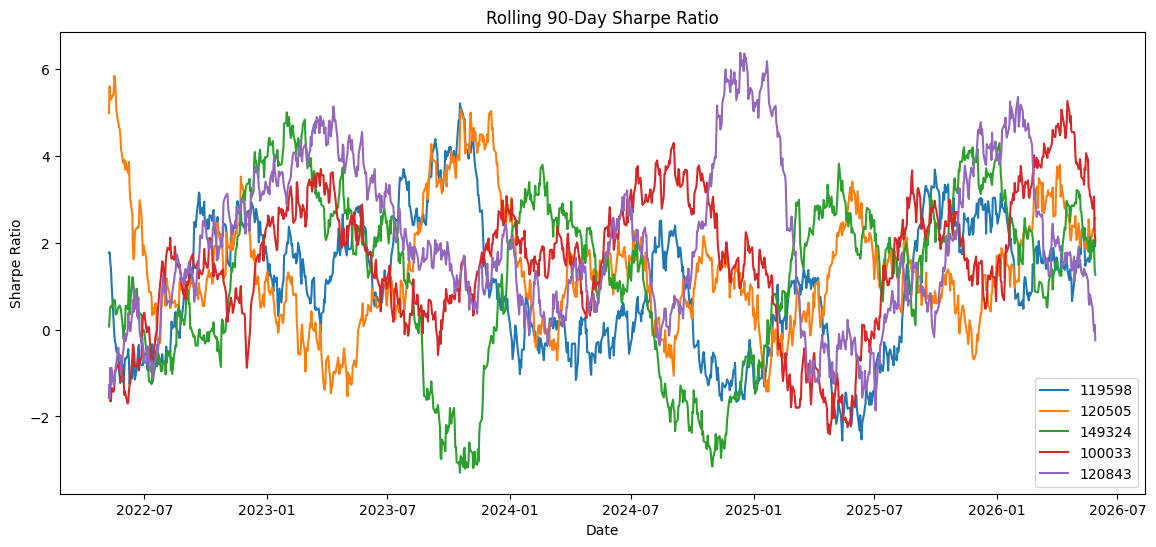

In [62]:
plt.figure(figsize=(14,6))

for code in top5_codes:

    temp = nav[
        nav['amfi_code']==code
    ].copy()

    rolling_sharpe = (

        temp['daily_return']
        .rolling(90)
        .mean()

        /

        temp['daily_return']
        .rolling(90)
        .std()

    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(code)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()
plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

Investor Cohort Analysis

In [63]:
txn['cohort_year'] = (

    txn
    .groupby('investor_id')
    ['transaction_date']
    .transform('min')
    .dt.year

)

In [64]:
cohort_summary = (

    txn
    .groupby('cohort_year')
    .agg({

        'amount_inr':'mean',

        'investor_id':'count'

    })

    .rename(columns={

        'amount_inr':'avg_sip_amount',

        'investor_id':'total_transactions'

    })

)

cohort_summary

,avg_sip_amount,total_transactions
cohort_year,,
2024,107422.541832,32499
2025,109158.577061,279


Top Fund Per Cohort

In [65]:
top_fund = (

    txn
    .groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')

)

top_fund = (

    top_fund
    .sort_values(
        'count',
        ascending=False
    )

    .drop_duplicates(
        'cohort_year'
    )

)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
67,2025,120507,12


SIP Continuity

In [66]:
sip = txn[
    txn['transaction_type']=='SIP'
].copy()

In [67]:
sip_counts = (

    sip
    .groupby('investor_id')
    .size()

)

eligible = sip_counts[
    sip_counts >= 6
].index

In [68]:
sip = sip[
    sip['investor_id']
    .isin(eligible)
]

In [69]:
sip = sip.sort_values(
    ['investor_id',
     'transaction_date']
)

In [70]:
sip['gap_days'] = (

    sip
    .groupby('investor_id')
    ['transaction_date']
    .diff()

    .dt.days

)

In [71]:
continuity = (

    sip
    .groupby('investor_id')
    ['gap_days']

    .mean()

    .reset_index()



)

In [72]:
continuity['status'] = np.where(

    continuity['gap_days'] > 35,

    'at-risk',

    'healthy'

)

continuity.head()

,investor_id,gap_days,status


In [73]:
continuity_rate = (

    continuity['status']
    == 'healthy'

).mean() * 100

print(
    f"Continuity Rate: {continuity_rate:.2f}%"
)

Continuity Rate: nan%


Sector HHI

In [74]:
hold['weight_sq'] = (
    hold['weight_pct'] / 100
) ** 2


In [75]:
hhi = (

    hold
    .groupby('amfi_code')
    ['weight_sq']

    .sum()

    .reset_index()

)

In [76]:
hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


Merge VaR with Fund Names

In [77]:
final_var = var_cvar_report.merge(

    perf[
        [
            'amfi_code',
            'scheme_name'
        ]
    ],

    on='amfi_code'

)

final_var.sort_values(
    'VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


Top 10 Highest Risk Funds

In [78]:
var_cvar_report.sort_values(
    'VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


Top 10 Most Concentrated Funds

In [79]:
hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


Cohort Visualization

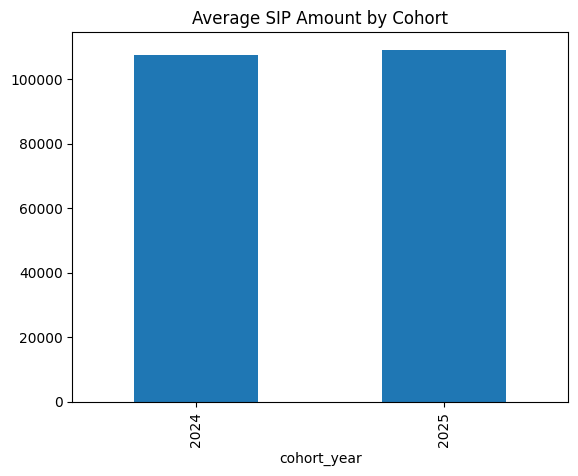

In [80]:
cohort_summary['avg_sip_amount'].plot(
    kind='bar'
)
plt.title("Average SIP Amount by Cohort")

plt.show()

## 5 Markdown Insights

# Insight 1
Funds with the most negative CVaR exhibit the highest downside tail risk.

# Insight 2
Rolling Sharpe ratios declined sharply during market correction periods.

# Insight 3
Recent investor cohorts contribute the largest share of new SIP inflows.

# Insight 4
A subset of investors shows SIP gaps greater than 35 days and are classified as at-risk.

# Insight 5
High-HHI funds are more concentrated and therefore potentially more vulnerable to sector-specific shocks.